In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import xarray as xr
pd.set_option('display.max_rows', 1000)
import numpy as np

In [5]:
#METADATA
station_metadata_1 = pd.read_csv('/home/queenle/station_FWI_data/raw_metadata//aes_stnhist20210111.csv')
station_metadata_2 = pd.read_csv('/home/queenle/station_FWI_data/raw_metadata//cwfis_allstn2023.csv')
station_metadata = pd.concat([station_metadata_1,station_metadata_2])

# STATION FWI
validation_study_FWI = pd.read_csv('/home/queenle/station_FWI_data/6month_fire_season_FWI/validation_study_FWI.csv')
validation_study_FWI['rep_date'] = pd.to_datetime(validation_study_FWI['rep_date'])
validation_study_FWI.set_index('rep_date', inplace=True)
validation_study_FWI = validation_study_FWI['1953':'2022']

validation_study_FWI.drop(['1092975'],axis=1,inplace=True) # drop selected sites (not enough data)
for site in ['1108446', '1086082', '3044232', '1100875', '1085836', '1046332','1017099', '1163842', '1015630', '1026562', '1047172', '1096631','1102415', '1092975']:
    validation_study_FWI.loc[validation_study_FWI.index.year==2017,site] = np.nan # remove selected 2017s (onyl have a few days in a multi-year gap)

#ERA5 FWI
box = [(32,55),(232,256)]

ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
ERA5 = ERA5.reindex(latitude=list(reversed(ERA5.latitude)))
ERA5 = ERA5.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
ERA5_canada = ERA5.sel(latitude=slice(47,box[0][1]),longitude=slice(box[1][0],box[1][1]))

# ERA5 station df
ERA5_station_dfs = []
for station in validation_study_FWI.columns:
    meta_station = station.split('.')[0]

    lat_lon = station_metadata.loc[station_metadata['aes'] == str(meta_station)][['lat','lon']]
    lat = lat_lon.values[0][0]
    lon = lat_lon.values[0][1]+360

    model_ts = ERA5.sel(latitude=lat,longitude=lon,method='nearest')
    model_df = pd.DataFrame.from_dict({'rep_date':model_ts.time,station:model_ts.data})
    model_df['rep_date'] = pd.to_datetime(model_df['rep_date'])
    model_df.set_index('rep_date', inplace=True)

    ERA5_station_dfs.append(model_df)
    
ERA5_station_df = pd.concat(ERA5_station_dfs,axis=1)


In [6]:
lats = []
lons = []
for site in validation_study_FWI:
    meta_station = site.split('.')[0]
    lat_lon = station_metadata.loc[station_metadata['aes'] == str(meta_station)][['lat','lon']]
    lat = lat_lon.values[0][0]
    lon = lat_lon.values[0][1]+360
    
    lats.append(lat)
    lons.append(lon)
    

In [7]:
lat_dict = {"coords": {"station": {"dims": "station", "data": validation_study_FWI.columns.tolist(), 
                                   "attrs": {"units": "s"}}},
            "dims": "station",
            "data": lats,
            "name": "lat",
            }

lon_dict = {"coords": {"station": {"dims": "station", "data": validation_study_FWI.columns.tolist(), 
                                   "attrs": {"units": "s"}}},
            "dims": "station",
            "data": lons,
            "name": "lon",
            }

In [8]:
lat_da = xr.DataArray.from_dict(lat_dict)
lon_da = xr.DataArray.from_dict(lon_dict)

coord_ds = xr.merge([lat_da,lon_da])

In [42]:
validation_study_FWI.index.values.shape

(70,)

In [37]:
validation_study_FWI.columns.values.shape

(280,)

In [34]:
validation_study_FWI.values.shape

(70, 280)

In [57]:
ds = xr.Dataset(
    data_vars={"FWI": (("station", "time"), validation_study_FWI.values.transpose())},
    coords={
        "station": ("station", validation_study_FWI.columns.values),
        "lon": ("station", lons),
        "lat": ("station", lats),
        "time": validation_study_FWI.index.values,
    },
)

In [54]:
# Rename the station coordinate so that you don't overwrite it
ds = ds.rename({"station": "station_id"})
# Create MultiIndex coordinate
ds_multiindex = ds.set_index(
    station=["lat", "lon"]
)
# Unstack the MultiIndex
ds_multiindex.unstack()

<xarray.Dataset>
Dimensions:     (lat: 151, lon: 193, station_id: 280, time: 70)
Coordinates:
  * lat         (lat) float64 48.3 48.37 48.38 48.4 ... 54.78 54.82 54.83 54.9
  * lon         (lon) float64 232.1 232.4 232.5 232.6 ... 255.8 255.8 256.0
  * station_id  (station_id) object '1018610' '1018620' ... '1113582' '1092975'
  * time        (time) datetime64[ns] 1953-12-31 1954-12-31 ... 2022-12-31
Data variables:
    FWI         (station_id, time) float64 7.503 6.025 6.766 ... nan nan nan

In [59]:
ds.set_index(site_id=("lat","lon")).unstack("site_id",sparse=True)

<xarray.Dataset>
Dimensions:  (lat: 151, lon: 193, station: 280, time: 70)
Coordinates:
  * lat      (lat) float64 48.3 48.37 48.38 48.4 ... 54.78 54.82 54.83 54.9
  * lon      (lon) float64 232.1 232.4 232.5 232.6 ... 255.4 255.8 255.8 256.0
  * station  (station) object '1018610' '1018620' ... '1113582' '1092975'
  * time     (time) datetime64[ns] 1953-12-31 1954-12-31 ... 2022-12-31
Data variables:
    FWI      (station, time) float64 7.503 6.025 6.766 10.22 ... nan nan nan nan

In [30]:
da = xr.DataArray(validation_study_FWI)
da = da.rename({'dim_1':'station'})

da = da.assign_coords({'lat':coord_ds['lat']})
da = da.assign_coords({'lon':coord_ds['lon']})

print(da.shape)

# Rename the station coordinate so that you don't overwrite it
da = da.rename({"station": "station_id"})
# Create MultiIndex coordinate
da_multiindex = da.set_index(
    station=["lat", "lon"]
)
# Unstack the MultiIndex
da = da_multiindex.unstack()

print(da.shape)

(70, 280)
(70, 280)


In [28]:
da_multiindex

<xarray.DataArray (rep_date: 70, station_id: 280)>
array([[ 7.50271739,  7.7625    ,  5.73240223, ...,         nan,
                nan,         nan],
       [ 6.02486188,  6.75966851,  4.26611111, ...,         nan,
                nan,         nan],
       [ 6.76566265,  7.11413043,  4.39294118, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,  8.20054348, ...,  8.25628743,
         6.98994413,         nan],
       [        nan,         nan, 11.75      , ..., 16.62582418,
        10.60434783,         nan],
       [        nan,         nan, 13.8375    , ..., 12.60340909,
        16.91194969,         nan]])
Coordinates:
  * rep_date    (rep_date) datetime64[ns] 1953-12-31 1954-12-31 ... 2022-12-31
  * station_id  (station_id) <U7 '1018610' '1018620' ... '1113582' '1092975'
  * station     (station) object MultiIndex
  * lat         (station) float64 48.42 48.65 49.72 50.68 ... 54.13 49.28 54.45
  * lon         (station) float64 236.6 236.6 235.1 232.6 ... 251.5 238.8 235.7

In [26]:
da

<xarray.DataArray (rep_date: 70, station_id: 280)>
array([[ 7.50271739,  7.7625    ,  5.73240223, ...,         nan,
                nan,         nan],
       [ 6.02486188,  6.75966851,  4.26611111, ...,         nan,
                nan,         nan],
       [ 6.76566265,  7.11413043,  4.39294118, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,  8.20054348, ...,  8.25628743,
         6.98994413,         nan],
       [        nan,         nan, 11.75      , ..., 16.62582418,
        10.60434783,         nan],
       [        nan,         nan, 13.8375    , ..., 12.60340909,
        16.91194969,         nan]])
Coordinates:
  * lat         (lat) float64 48.3 48.37 48.38 48.4 ... 54.78 54.82 54.83 54.9
  * lon         (lon) float64 232.1 232.4 232.5 232.6 ... 255.8 255.8 256.0
  * rep_date    (rep_date) datetime64[ns] 1953-12-31 1954-12-31 ... 2022-12-31
  * station_id  (station_id) <U7 '1018610' '1018620' ... '1113582' '1092975'

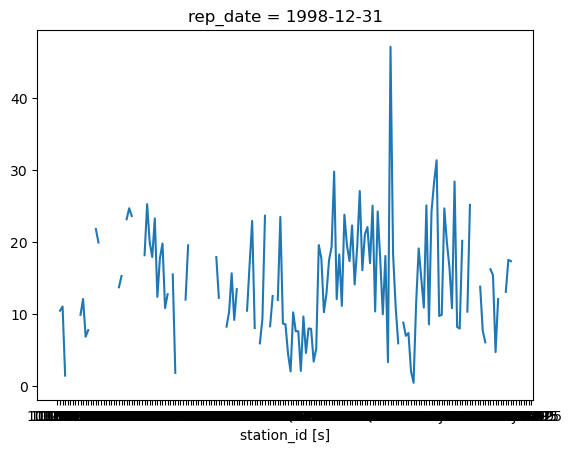

In [27]:
da.isel(rep_date=45).plot()

In [18]:
da = da.assign_coords({'lat':coord_ds['lat']})
da = da.assign_coords({'lon':coord_ds['lon']})

# Rename the station coordinate so that you don't overwrite it
da = da.rename({"station": "station_id"})
# Create MultiIndex coordinate
da_multiindex = da.set_index(
    station=["lat", "lon"]
)
# Unstack the MultiIndex
da = da_multiindex.unstack()

<xarray.DataArray (rep_date: 70, station: 280)>
array([[ 7.50271739,  7.7625    ,  5.73240223, ...,         nan,
                nan,         nan],
       [ 6.02486188,  6.75966851,  4.26611111, ...,         nan,
                nan,         nan],
       [ 6.76566265,  7.11413043,  4.39294118, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,  8.20054348, ...,  8.25628743,
         6.98994413,         nan],
       [        nan,         nan, 11.75      , ..., 16.62582418,
        10.60434783,         nan],
       [        nan,         nan, 13.8375    , ..., 12.60340909,
        16.91194969,         nan]])
Coordinates:
  * rep_date  (rep_date) datetime64[ns] 1953-12-31 1954-12-31 ... 2022-12-31
  * station   (station) <U7 '1018610' '1018620' ... '1113582' '1092975'
    lat       (station) float64 48.42 48.65 49.72 50.68 ... 54.13 49.28 54.45
    lon       (station) float64 236.6 236.6 235.1 232.6 ... 251.5 238.8 235.7

In [22]:
# Rename the station coordinate so that you don't overwrite it
da = da.rename({"station": "station_id"})
# Create MultiIndex coordinate
da_multiindex = da.set_index(
    station=["lat", "lon"]
)
# Unstack the MultiIndex
da = da_multiindex.unstack()

<xarray.DataArray (rep_date: 70, station_id: 280)>
array([[ 7.50271739,  7.7625    ,  5.73240223, ...,         nan,
                nan,         nan],
       [ 6.02486188,  6.75966851,  4.26611111, ...,         nan,
                nan,         nan],
       [ 6.76566265,  7.11413043,  4.39294118, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,  8.20054348, ...,  8.25628743,
         6.98994413,         nan],
       [        nan,         nan, 11.75      , ..., 16.62582418,
        10.60434783,         nan],
       [        nan,         nan, 13.8375    , ..., 12.60340909,
        16.91194969,         nan]])
Coordinates:
  * lat         (lat) float64 48.3 48.37 48.38 48.4 ... 54.78 54.82 54.83 54.9
  * lon         (lon) float64 232.1 232.4 232.5 232.6 ... 255.8 255.8 256.0
  * rep_date    (rep_date) datetime64[ns] 1953-12-31 1954-12-31 ... 2022-12-31
  * station_id  (station_id) <U7 '1018610' '1018620' ... '1113582' '1092975'

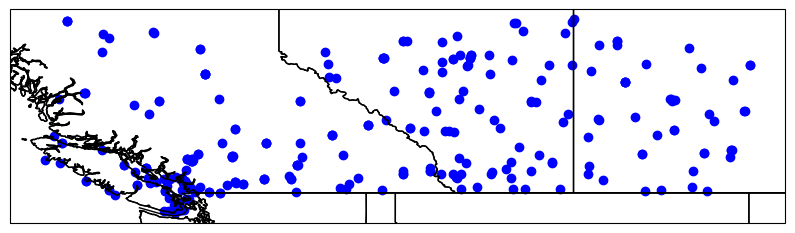

In [3]:
fig,axs = plt.subplots(figsize=(10,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

for site in validation_study_FWI.columns:

    station = site.split('.')[0]
    lat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]
    lat = lat_lon.values[0][0]
    lon = lat_lon.values[0][1]+360

    axs.scatter(lon,lat,c='blue')

axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)
#axs.set_extent([232.5,255, 32.5,54.18])

plt.show()
plt.close()

In [56]:
'''
Plot station density maps for Canada with reduced Alberta stations each year to make movie.
'''

for year in validation_study_FWI.index.year.values:
    
    fig,axs = plt.subplots(figsize=(10,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

    sites = validation_study_FWI.loc[validation_study_FWI.index.year==year].dropna(axis=1).columns
    
    for site in sites:
        
        station = site.split('.')[0]
        lat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]
        lat = lat_lon.values[0][0]
        lon = lat_lon.values[0][1]+360
        
        axs.scatter(lon,lat,c='blue')
    
    axs.coastlines()  # cartopy function
    axs.add_feature(cf.BORDERS)
    axs.add_feature(cf.STATES)
    axs.set_extent([232.5,255, 32.5,54.18])
    
    axs.text(0.1,0.1,str(year),transform=axs.transAxes,fontsize=22)

    plt.savefig('/home/queenle/fire_attribution/figures/plots/station_density/canada_reduced_AB/'+str(year)+'.png',dpi=300)
    plt.close()

In [172]:
'''
Plot station density maps for each year to make movie.
'''

for year in full_study_area_FWI.index.year.values:
    
    fig,axs = plt.subplots(figsize=(10,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

    sites = full_study_area_FWI.loc[full_study_area_FWI.index.year==year].dropna(axis=1).columns
    
    for site in sites:
        
        station = site.split('.')[0]
        lat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]
        lat = lat_lon.values[0][0]
        lon = lat_lon.values[0][1]+360
        
        axs.scatter(lon,lat,c='blue')
    
    axs.coastlines()  # cartopy function
    axs.add_feature(cf.BORDERS)
    axs.add_feature(cf.STATES)
    axs.set_extent([232.5,255, 32.5,54.18])
    
    axs.text(0.1,0.1,str(year),transform=axs.transAxes,fontsize=22)

    plt.savefig('/home/queenle/fire_attribution/figures/plots/station_density/'+str(year)+'.png',dpi=300)
    plt.close()

In [48]:
'''
MEAN ABSOLUTE ERROR, MEAN PERCENTAGE ERROR, and station vs ERA5 REGIONAL TIME SERIES
'''

absolute_error_dfs = []
absolute_percent_error_dfs = []
bias_error_dfs = []
anomaly_error_dfs = []
correlation_dict = {}
for station in validation_study_FWI.columns:
    
    station_df = validation_study_FWI[station]
    ERA5_df = ERA5_station_df[station]
    
    # absolute error
    station_absolute_error = (station_df - ERA5_df).abs()
    station_absolute_error.name = station
    absolute_error_dfs.append(station_absolute_error)
    
    # absolute percentage error
    station_absolute_percent_error = ((station_df - ERA5_df)/station_df).abs()
    station_absolute_percent_error.name = station
    absolute_percent_error_dfs.append(station_absolute_percent_error)
    
    # bias error
    station_bias_error = station_df - ERA5_df
    station_bias_error.name = station
    bias_error_dfs.append(station_bias_error)
    
    # correlation
    correlation_dict[station] = [station_df.corr(ERA5_df)]
    
    # anomaly_error
    station_anomaly_error = (station_df - station_df.mean()) - (ERA5_df - ERA5_df.mean())
    station_anomaly_error.name = station
    anomaly_error_dfs.append(station_anomaly_error)
    
correlation_df = pd.DataFrame.from_dict(correlation_dict)
absolute_error_df = pd.concat(absolute_error_dfs,axis=1)
absolute_percent_error_df = pd.concat(absolute_percent_error_dfs,axis=1)
bias_error_df = pd.concat(bias_error_dfs,axis=1)
anomaly_error_df = pd.concat(anomaly_error_dfs,axis=1)


/nesi/project/niwa00015/queenle/my_env38/lib/python3.10/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/nesi/project/niwa00015/queenle/my_env38/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/nesi/project/niwa00015/queenle/my_env38/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [19]:
absolute_percent_error_df

,1018610,1018620,1021830,1026270,1032730,1037650,1040390,1077500,1084350,1096450,...,1161663,1173220,4016566,4065063,1113582,1092972,3035202,1123965,306E304,4075522
rep_date,,,,,,,,,,,,,,,,,,,,,
1951-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1952-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1953-12-31,0.365028,0.133650,0.239697,0.198865,NaN,0.375545,0.500906,0.476234,0.402614,0.381127,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1954-12-31,0.452341,0.176908,0.240198,0.058846,NaN,0.148469,NaN,0.600155,0.367970,0.851374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1955-12-31,0.513330,0.139212,0.021666,0.265648,NaN,0.415917,NaN,0.814989,0.162157,0.622109,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1956-12-31,0.524811,0.315492,0.115277,0.001943,NaN,1.131690,NaN,0.663366,0.265593,0.334296,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1957-12-31,0.562222,0.105778,0.221988,0.500969,NaN,0.450637,NaN,0.561849,0.020279,0.473995,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1958-12-31,0.278823,0.163857,0.139107,0.043854,NaN,1.549235,NaN,0.546881,0.147008,0.183479,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-12-31,0.515980,0.194236,0.469300,0.173392,0.260989,0.863388,NaN,0.555855,0.541975,0.207399,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
validation_study_FWI.mean(axis=1)

rep_date
1953-12-31    13.968549
1954-12-31    10.181591
1955-12-31    15.680915
1956-12-31    15.891491
1957-12-31    14.071896
1958-12-31    19.390406
1959-12-31    14.138010
1960-12-31    17.004562
1961-12-31    19.096487
1962-12-31    13.101861
1963-12-31    13.190282
1964-12-31    13.700273
1965-12-31    12.994261
1966-12-31    13.654864
1967-12-31    20.824214
1968-12-31    12.310767
1969-12-31    14.355416
1970-12-31    15.988267
1971-12-31    14.711282
1972-12-31    12.826962
1973-12-31    15.512395
1974-12-31    13.281999
1975-12-31    11.434176
1976-12-31    12.209664
1977-12-31    11.862425
1978-12-31    11.060266
1979-12-31    14.702606
1980-12-31    11.202229
1981-12-31    11.522877
1982-12-31    10.167650
1983-12-31    11.429233
1984-12-31    13.128270
1985-12-31    13.819233
1986-12-31    10.969034
1987-12-31    14.833548
1988-12-31    14.492695
1989-12-31    10.895306
1990-12-31    13.438628
1991-12-31    11.832190
1992-12-31    12.481304
1993-12-31     8.439963
1994-12

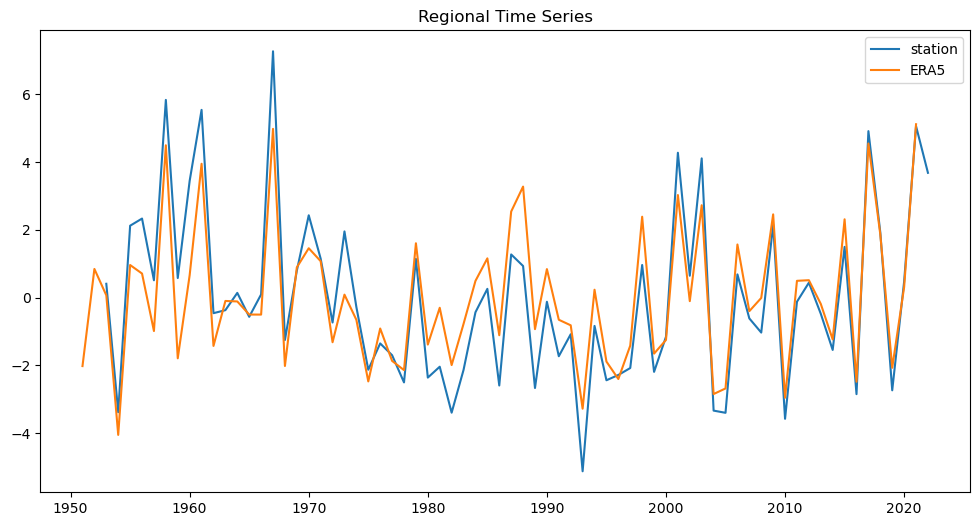

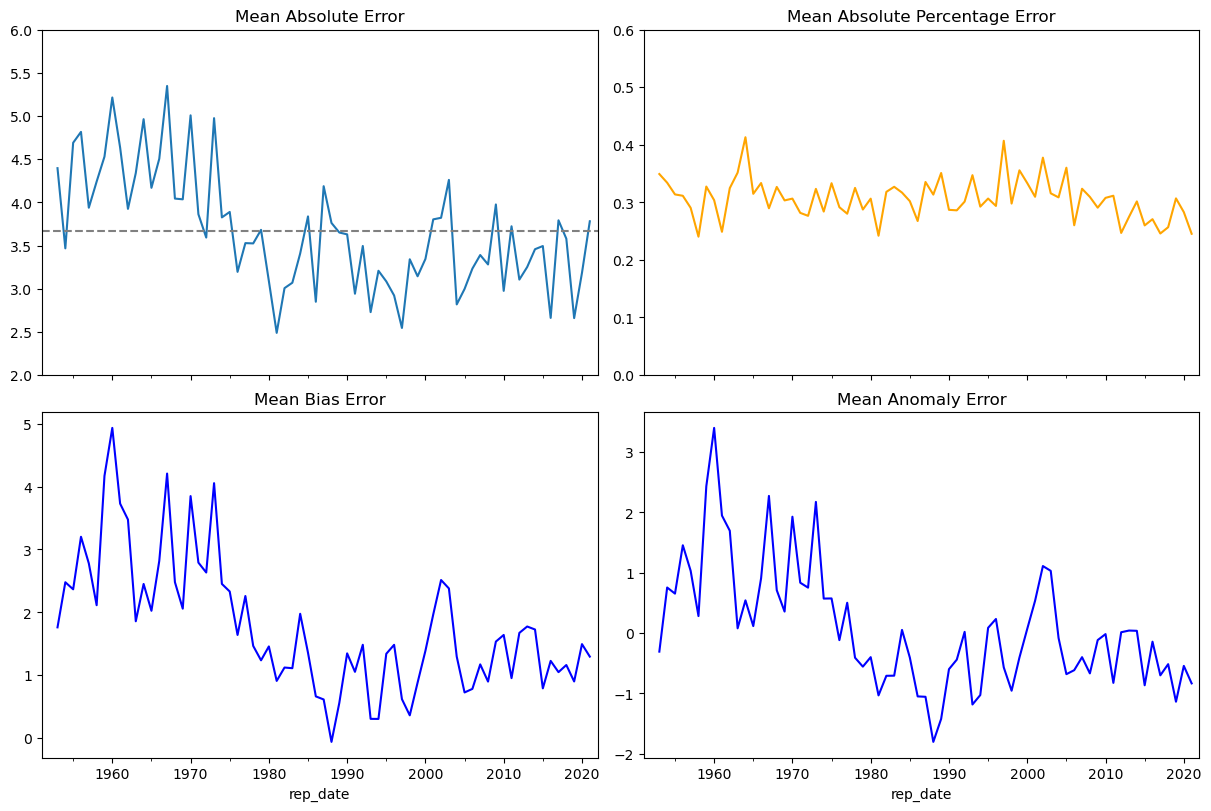

In [49]:
# plot regional time series
fig,ax = plt.subplots(figsize=(12,6))
years = validation_study_FWI.index.year.values
ts = validation_study_FWI.mean(axis=1).values
ax.plot(years,ts-ts.mean(),label='station')

years = ERA5_station_df.index.year.values
ts = ERA5_station_df.mean(axis=1).values
ax.plot(years,ts-ts.mean(),label='ERA5')
ax.set_title('Regional Time Series')
ax.legend()

plt.show()
plt.close()

# plot errors

fig,axs = plt.subplots(2,2,figsize=(12,8),layout='constrained',sharex=True)
axs = axs.flatten()

mean_absolute_error = absolute_error_df.mean(axis=1)
mean_absolute_error.plot(ax=axs[0])
axs[0].axhline(y=0,c='grey')
axs[0].axhline(y=mean_absolute_error.mean(),c='grey',linestyle='--')
axs[0].set_ylim(2,6)
axs[0].set_title('Mean Absolute Error')

mean_absolute_percent_error = absolute_percent_error_df.mean(axis=1)
mean_absolute_percent_error.plot(ax=axs[1], c='orange')
axs[1].set_ylim(0,0.6)
axs[1].set_title('Mean Absolute Percentage Error')

mean_bias_error = bias_error_df.mean(axis=1)
mean_bias_error.plot(ax=axs[2], c='blue')
axs[2].set_title('Mean Bias Error')

mean_anomaly_error = anomaly_error_df.mean(axis=1)
mean_anomaly_error.plot(ax=axs[3], c='blue')
axs[3].set_title('Mean Anomaly Error')

plt.show()
plt.close()

nan
9.236218404616269


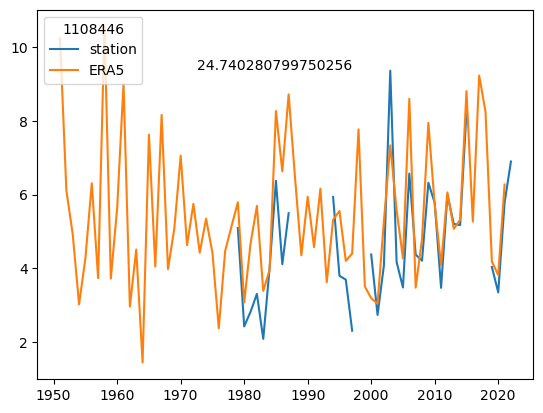

nan
9.729215938939257


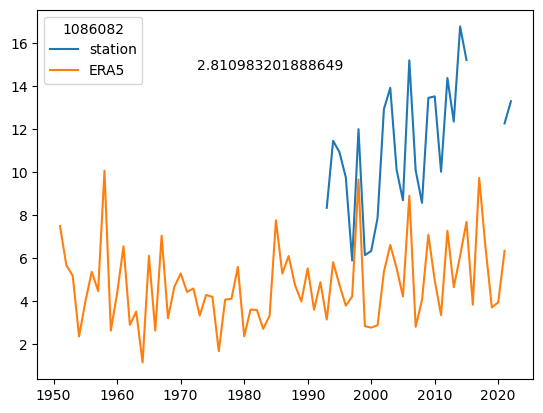

nan
35.47792932707188


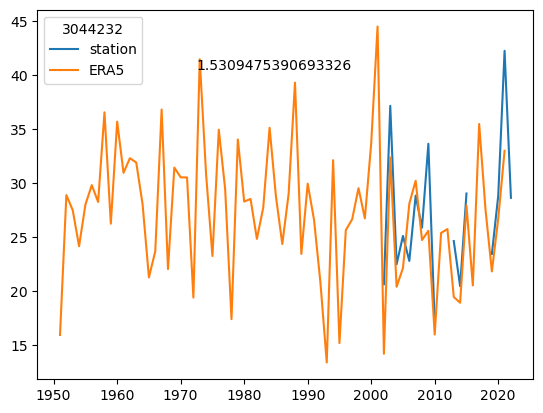

nan
8.44568682724635


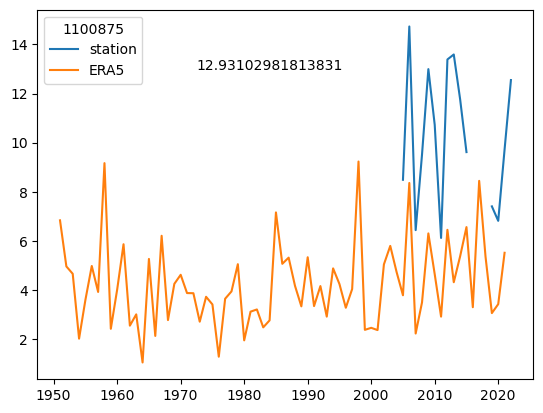

nan
5.822625528015781


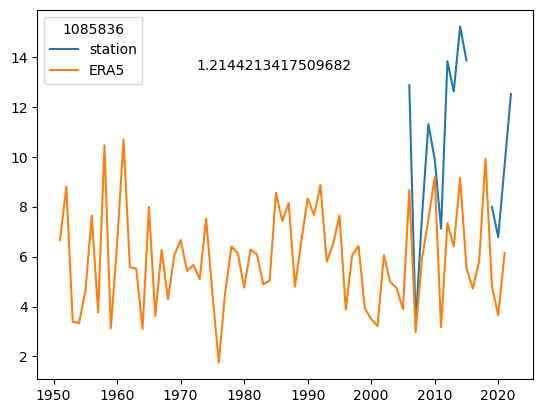

nan
4.673952253661686


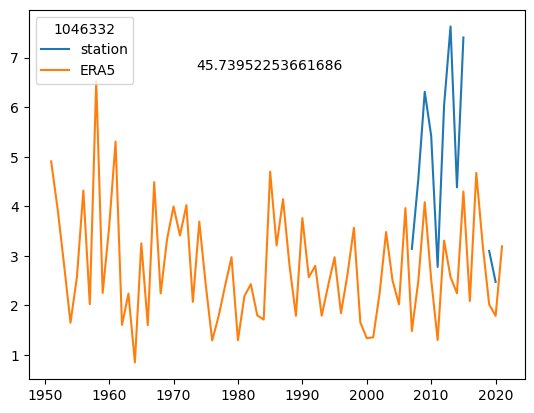

nan
7.07785373016939


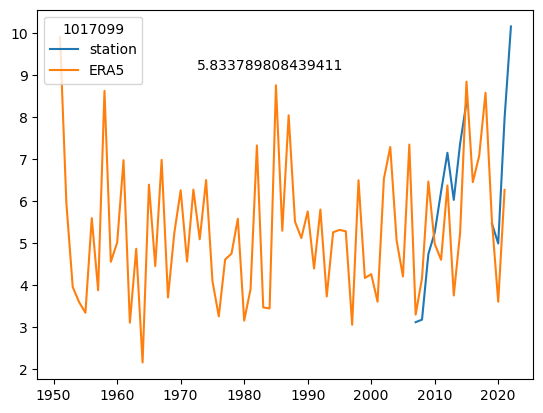

nan
29.209794758536667


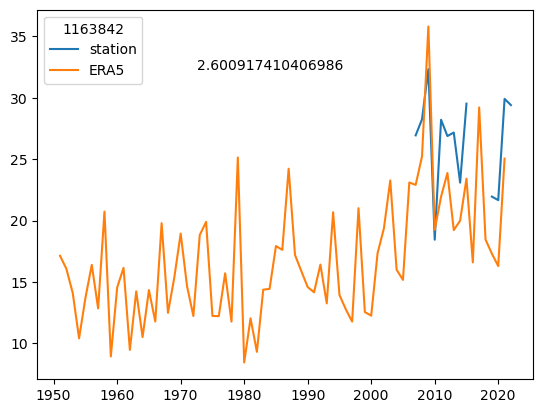

nan
14.722876924164382


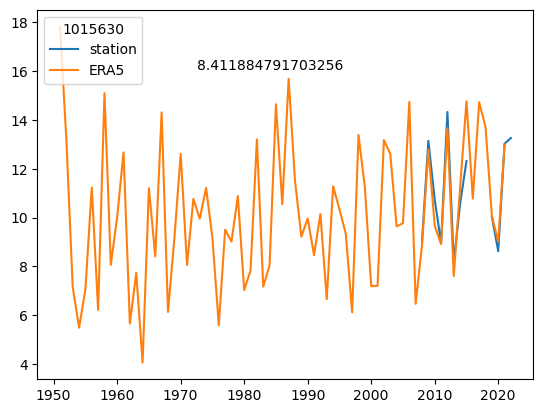

nan
10.510955112225673


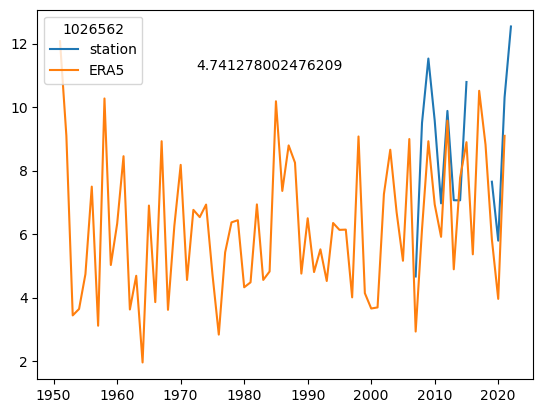

nan
5.970230611021167


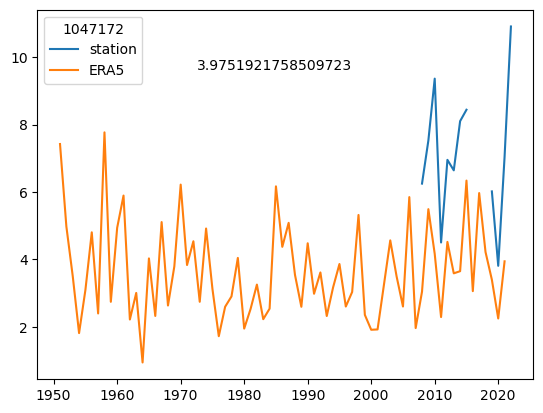

nan
14.933106344936725


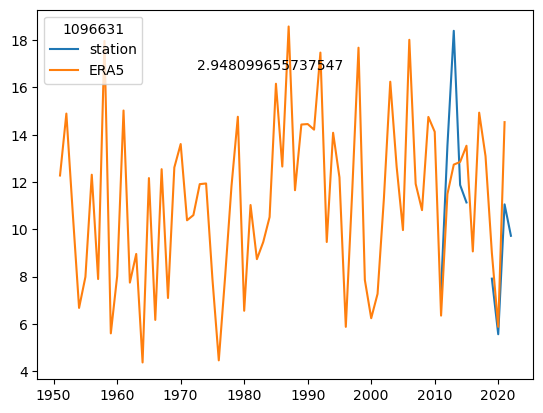

nan
9.236218404616269


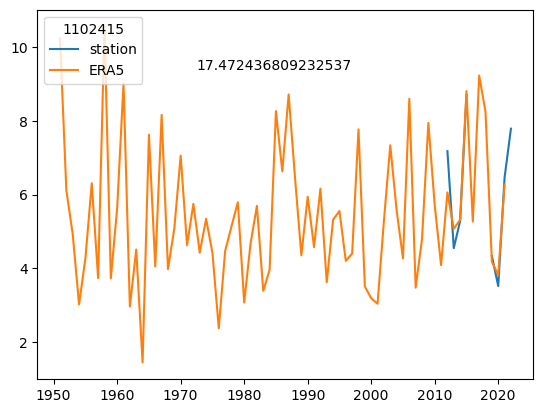

nan
12.34971015459544


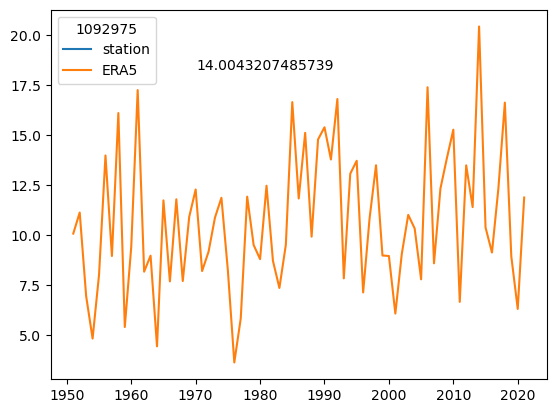

In [50]:
sites = ['1108446', '1086082', '3044232', '1100875', '1085836', '1046332',
       '1017099', '1163842', '1015630', '1026562', '1047172', '1096631',
       '1102415', '1092975']
for site in sites:
        
    years = validation_study_FWI.index.year.values
    ts = validation_study_FWI[site].values
    plt.plot(years,ts,label='station')
    print(validation_study_FWI[site].loc[validation_study_FWI[site].index.year == 2017].values[0])

    years = ERA5_station_df.index.year.values
    ts = ERA5_station_df[site].values
    plt.plot(years,ts,label='ERA5')
    print(ERA5_station_df[site].loc[ERA5_station_df[site].index.year == 2017].values[0])
    
    
    plt.legend(title=site, loc='upper left')
    
    plt.text(s=str(series.loc[series.index==site].values[0]),x=0.05,y=0.6,transform=ax.transAxes)

    plt.show()
    plt.close()

In [37]:
for site in absolute_percent_error_df:
    
    ts = absolute_percent_error_df[site]
    
    print(ts)
    break

rep_date
1951-12-31         NaN
1952-12-31         NaN
1953-12-31    0.365028
1954-12-31    0.452341
1955-12-31    0.513330
1956-12-31    0.524811
1957-12-31    0.562222
1958-12-31    0.278823
1959-12-31    0.515980
1960-12-31    0.578945
1961-12-31    0.364552
1962-12-31    0.506445
1963-12-31    0.364739
1964-12-31    0.666651
1965-12-31    0.254438
1966-12-31    0.280129
1967-12-31    0.220287
1968-12-31    0.391438
1969-12-31    0.510416
1970-12-31    0.254253
1971-12-31    0.290818
1972-12-31    0.278603
1973-12-31         NaN
1974-12-31         NaN
1975-12-31         NaN
1976-12-31         NaN
1977-12-31         NaN
1978-12-31         NaN
1979-12-31         NaN
1980-12-31         NaN
1981-12-31         NaN
1982-12-31         NaN
1983-12-31         NaN
1984-12-31         NaN
1985-12-31         NaN
1986-12-31         NaN
1987-12-31         NaN
1988-12-31         NaN
1989-12-31         NaN
1990-12-31         NaN
1991-12-31         NaN
1992-12-31         NaN
1993-12-31         NaN
19

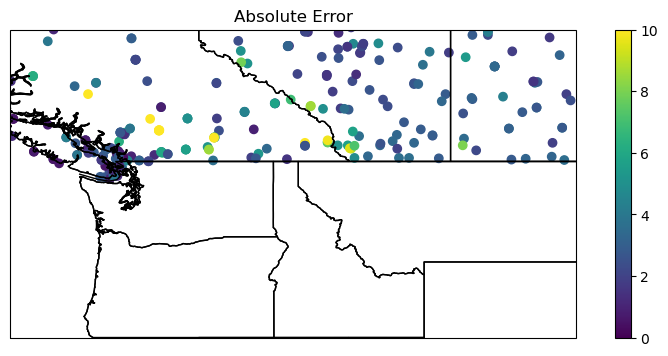

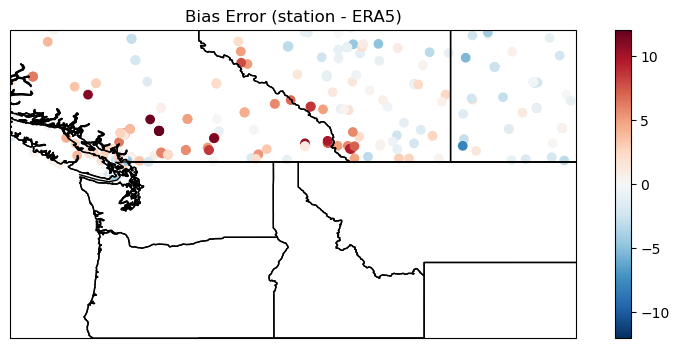

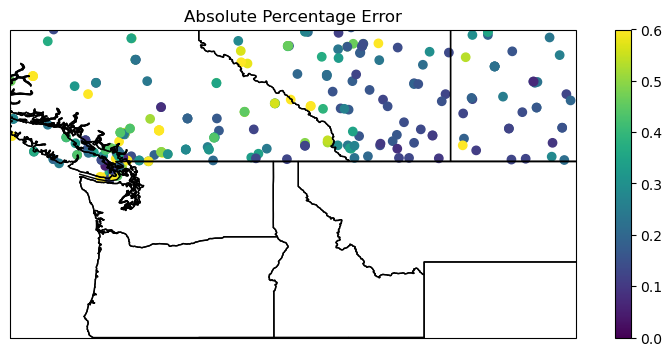

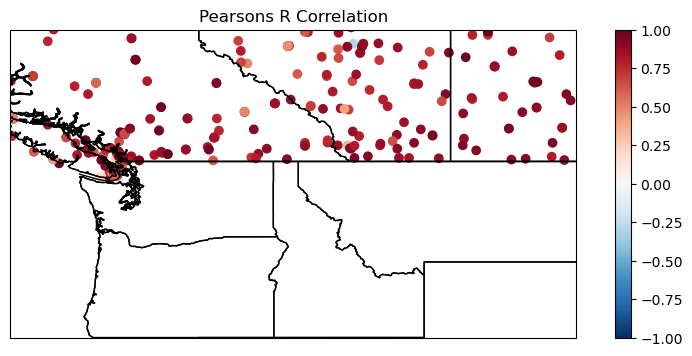

In [54]:
'''
MAPS of 
(a) bias error
(b) percentage error
(c) correlation
'''

for i,df in enumerate(([absolute_error_df,bias_error_df,absolute_percent_error_df,correlation_df])):
    
    fig,axs = plt.subplots(figsize=(10,4),subplot_kw=dict(projection=ccrs.PlateCarree()))

    temporal_mean = df.mean()
    
    lats = []
    lons = []
    cs = []
    for site in temporal_mean.index:
        station = site.split('.')[0]
        lat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]
        lats.append(lat_lon.values[0][0])
        lons.append(lat_lon.values[0][1]+360)
        cs.append(temporal_mean[site])
        
    if i == 0:
        im = axs.scatter(lons,lats,c=cs,vmin=0,vmax=10)#5,cmap='RdBu_r')
        axs.set_title('Absolute Error')
    if i == 1:
        im = axs.scatter(lons,lats,c=cs,vmin=-12,vmax=12,cmap='RdBu_r')
        axs.set_title('Bias Error (station - ERA5)')
    elif i == 2:
        im = axs.scatter(lons,lats,c=cs,vmin=0,vmax=0.6)
        axs.set_title('Absolute Percentage Error')
    elif i == 3:
        im = axs.scatter(lons,lats,c=cs,vmin=-1,vmax=1,cmap='RdBu_r')
        axs.set_title('Pearsons R Correlation')
    
    fig.colorbar(im, ax=axs)
    axs.coastlines()  # cartopy function
    axs.add_feature(cf.BORDERS)
    axs.add_feature(cf.STATES)
    axs.set_extent([232.5,255, 42,54.18])

    plt.show()
    plt.close()
        

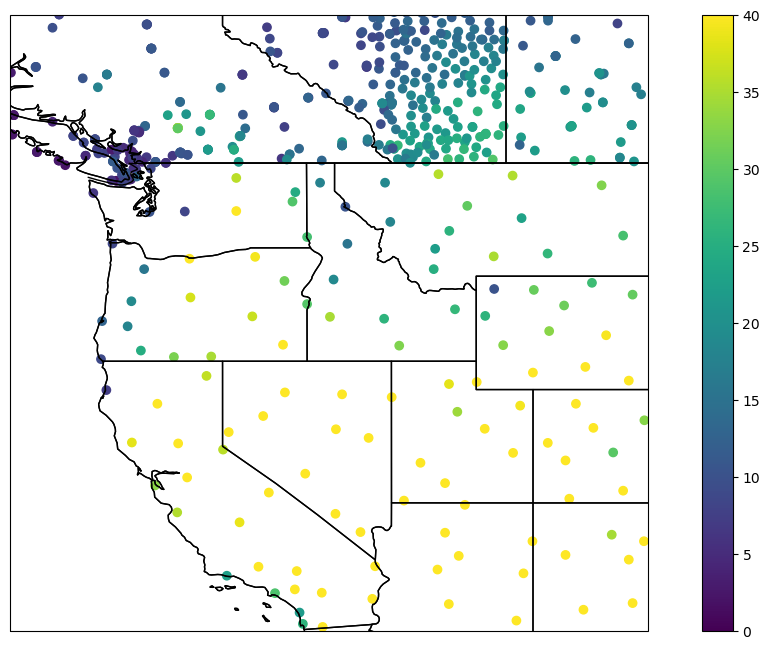

In [63]:

fig,axs = plt.subplots(figsize=(14,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

temporal_mean = full_study_area_FWI.mean()

lats = []
lons = []
cs = []
for site in temporal_mean.index:
    station = site.split('.')[0]
    lat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]
    lats.append(lat_lon.values[0][0])
    lons.append(lat_lon.values[0][1]+360)
    cs.append(temporal_mean[site])

im = axs.scatter(lons,lats,c=cs,vmin=0,vmax=40)#5,cmap='RdBu_r')

fig.colorbar(im, ax=axs)
axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)
axs.set_extent([232.5,255, 32.5,54.18])

plt.show()
plt.close()


In [37]:
correlation_df

,1021830,1026270,1032730,1037650,1040390,1077500,1084350,1096450,1096630,1100030,...,4065063,1113582,1036206.1,1092972,3035202,1123965,306E304,4075522,3033884,3067373
0,0.794959,0.8964,0.846212,0.801894,-0.251256,0.741104,0.772302,0.96956,0.871219,0.924245,...,0.992102,0.999995,NaN,NaN,NaN,0.731544,NaN,0.694683,NaN,NaN


rep_date
1951-12-31         NaN
1952-12-31         NaN
1953-12-31         NaN
1954-12-31         NaN
1955-12-31         NaN
1956-12-31         NaN
1957-12-31         NaN
1958-12-31         NaN
1959-12-31         NaN
1960-12-31         NaN
1961-12-31         NaN
1962-12-31         NaN
1963-12-31         NaN
1964-12-31         NaN
1965-12-31         NaN
1966-12-31         NaN
1967-12-31         NaN
1968-12-31         NaN
1969-12-31         NaN
1970-12-31         NaN
1971-12-31         NaN
1972-12-31         NaN
1973-12-31         NaN
1974-12-31         NaN
1975-12-31         NaN
1976-12-31         NaN
1977-12-31         NaN
1978-12-31         NaN
1979-12-31         NaN
1980-12-31         NaN
1981-12-31         NaN
1982-12-31         NaN
1983-12-31         NaN
1984-12-31         NaN
1985-12-31         NaN
1986-12-31         NaN
1987-12-31         NaN
1988-12-31         NaN
1989-12-31         NaN
1990-12-31         NaN
1991-12-31         NaN
1992-12-31         NaN
1993-12-31         NaN
19

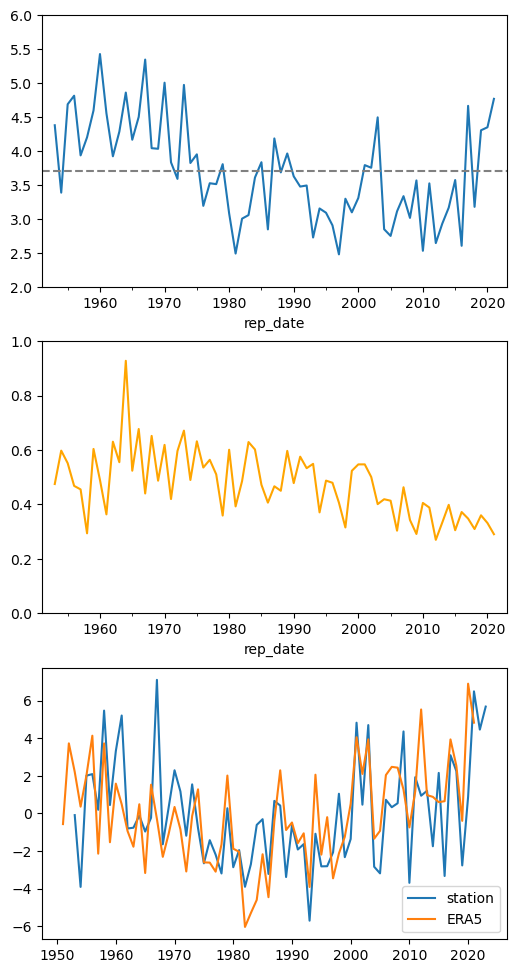

In [32]:
'''
MEAN ABSOLUTE ERROR, MEAN PERCENTAGE ERROR, and station vs ERA5 REGIONAL TIME SERIES
'''

removed_small  = full_study_area_FWI.where(full_study_area_FWI>0.5)

fig,axs = plt.subplots(3,1,figsize=(6,12))
axs = axs.flatten()

error_dfs = []
percent_error_dfs = []
for station in removed_small.columns:
    
    if full_study_area_FWI[station].isnull().all():
        continue
        
    meta_station = station.split('.')[0]

    lat_lon = station_metadata.loc[station_metadata['aes'] == str(meta_station)][['lat','lon']]
    lat = lat_lon.values[0][0]
    lon = lat_lon.values[0][1]+360
        
    station_ts = full_study_area_FWI[station]
    
    model_ts = ERA5.sel(latitude=lat,longitude=lon,method='nearest')
    model_df = pd.DataFrame.from_dict({'rep_date':model_ts.time,'model_ts':model_ts.data})
    model_df['rep_date'] = pd.to_datetime(model_df['rep_date'])
    model_df.set_index('rep_date', inplace=True)
    
    merge_df = pd.concat([station_ts,model_df],axis=1)
    station_error_df = merge_df[station] - merge_df['model_ts']
    station_error_df.name = station
    error_dfs.append(station_error_df)
    
    station_percent_error = (merge_df[station] - merge_df['model_ts'])/merge_df['model_ts']
    station_percent_error.name = station
    percent_error_dfs.append(station_percent_error)
    
error_df = pd.concat(error_dfs,axis=1)
mean_absolute_error = error_df.abs().mean(axis=1)
mean_absolute_error.plot(ax=axs[0])
mean_mean = mean_absolute_error.mean()
axs[0].axhline(y=0,c='grey')
axs[0].axhline(y=mean_mean,c='grey',linestyle='--')
axs[0].set_ylim(2,6)

percent_error_df = pd.concat(percent_error_dfs,axis=1)
mean_absolute_percent_error = percent_error_df.abs().mean(axis=1)
mean_absolute_percent_error.plot(ax=axs[1], c='orange')
axs[1].set_ylim(0,1)

years = canada_FWI.index.year.values
ts = canada_FWI.mean(axis=1).values
axs[2].plot(years,ts-ts.mean(),label='station')

model_ts = ERA5.mean(['latitude','longitude']).values
model_years = ERA5.time.dt.year.values
axs[2].plot(model_years, model_ts - model_ts.mean(),label='ERA5')

axs[2].legend()


In [43]:
canada_FWI
USA_FWI = full_study_area_FWI.drop(canada_FWI.columns,axis=1)

In [44]:
USA_FWI

,1018610,1018620,1031110,1035940,1176750,1020270,1018642,1100120,1166945,3012295,...,72772,72773,72775,72777,72779,72783,72785,72791,72797,74230
rep_date,,,,,,,,,,,,,,,,,,,,,
1953-12-31,7.502717,7.762500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1954-12-31,6.024862,6.759669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1955-12-31,6.765663,7.114130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1956-12-31,10.216304,7.882609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1957-12-31,10.320442,6.919565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1958-12-31,11.755978,11.808152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-12-31,9.999457,6.786413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-12-31,11.643478,11.149457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-12-31,10.526630,11.894022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


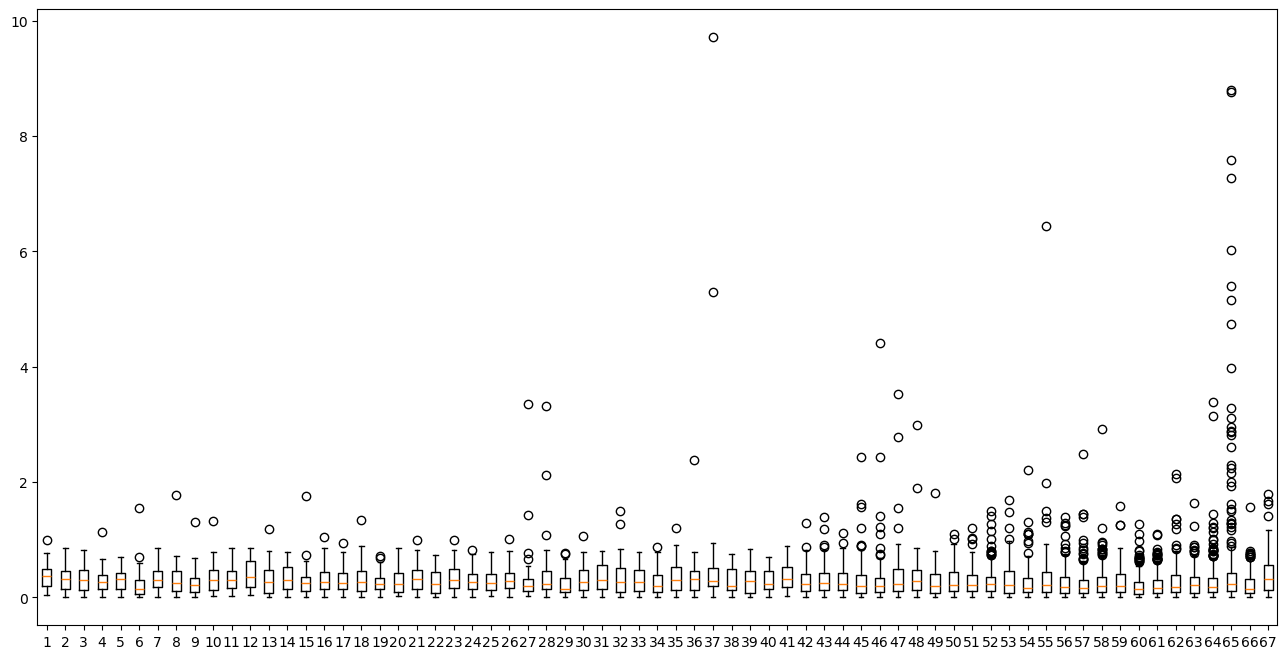

In [146]:
fig,axs = plt.subplots(figsize=(16,8))
val_list = []
for year in range(1953,2020):
    vals = anomaly_df.abs().loc[anomaly_df.index.year==year].dropna(axis=1).values
    val_list.append(vals[0])
    
plt.boxplot(val_list)
plt.show()

In [130]:
sub_df = anomaly_df.abs().loc[anomaly_df.index.year==2017]

for station in sub_df:
    if sub_df[station][0] > 25:
        print(station)
    

1100030.1
1046332
1100881


/tmp/ipykernel_32399/994112719.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if sub_df[station][0] > 25:


                  ABBOTSFORD+A
nan

                   PORT+MELLON
0.1

 BLACKCOMB+BASE+SLIDING+CENTER
0.1999999999999999



/tmp/ipykernel_32399/4157257472.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(new.loc[new.index.year==2017][0])
/tmp/ipykernel_32399/4157257472.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(full_study_area_FWI['1046332'].loc[full_study_area_FWI['1046332'].index.year==2017][0])
/tmp/ipykernel_32399/4157257472.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(full_study_area_FWI['1100881'].loc[full_s

"\nlat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]\nlat = lat_lon.values[0][0]\nlon = lat_lon.values[0][1]+360\n"

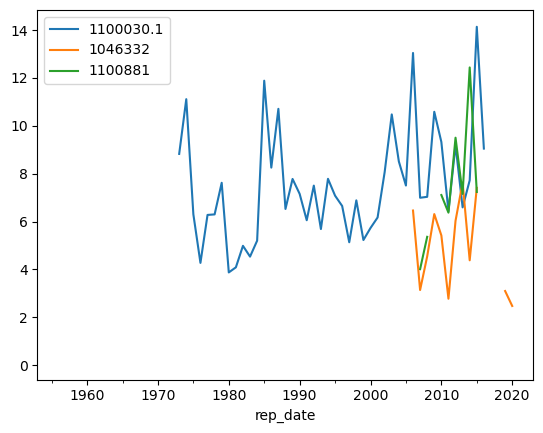

In [144]:
new  = full_study_area_FWI['1100030.1'].where(full_study_area_FWI['1100030.1']>1)
new.plot(label='1100030.1')
full_study_area_FWI['1046332'].plot(label='1046332')
full_study_area_FWI['1100881'].plot(label='1100881')

plt.legend()
'''
print(station_metadata.loc[station_metadata['aes'] == '1100030']['name'].values[0])
print(full_study_area_FWI['1100030.1'].loc[full_study_area_FWI['1100030.1'].index.year==2017][0])
print('')
'''
print(station_metadata.loc[station_metadata['aes'] == '1100030']['name'].values[0])
print(new.loc[new.index.year==2017][0])
print('')
print(station_metadata.loc[station_metadata['aes'] == '1046332']['name'].values[0])
print(full_study_area_FWI['1046332'].loc[full_study_area_FWI['1046332'].index.year==2017][0])
print('')
print(station_metadata.loc[station_metadata['aes'] == '1100881']['name'].values[0])
print(full_study_area_FWI['1100881'].loc[full_study_area_FWI['1100881'].index.year==2017][0])
print('')


'''
lat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]
lat = lat_lon.values[0][0]
lon = lat_lon.values[0][1]+360
'''

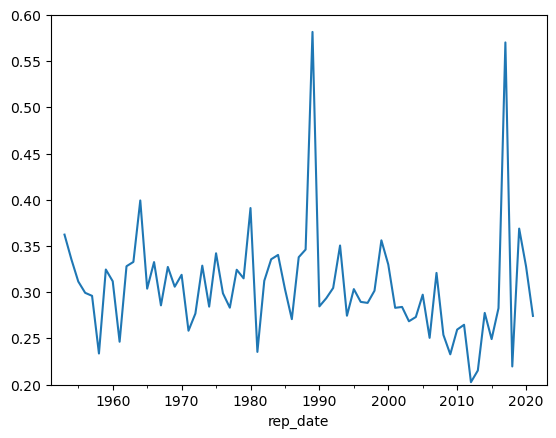

In [147]:
mean_anomaly = anomaly_df.abs().mean(axis=1)
mean_anomaly.plot()
plt.ylim(0.2,0.6)
mean_mean = mean_anomaly.mean()
#plt.axhline(y=0,c='grey')
#plt.axhline(y=mean_mean,c='grey',linestyle='--')


In [95]:
full_study_area_FWI.min()

1018610     6.024862
1018620     6.759669
1021830     4.266111
1026270     0.632065
1031110          NaN
             ...    
72785      21.250980
72791       5.481522
72797       3.643478
74230      16.815686
3067373    10.223214
Length: 650, dtype: float64

In [64]:
diff_dfs = []
for station in full_study_area_FWI.columns:
    
    meta_station = station.split('.')[0]
    
    if full_study_area_FWI[station].isnull().all():
            remove_sites.append(station)
            continue

    lat_lon = station_metadata.loc[station_metadata['aes'] == str(meta_station)][['lat','lon']]
    lat = lat_lon.values[0][0]
    lon = lat_lon.values[0][1]+360
        
    station_ts = full_study_area_FWI[station]
    
    model_ts = ERA5.sel(latitude=lat,longitude=lon,method='nearest')
    model_df = pd.DataFrame.from_dict({'rep_date':model_ts.time,'model_ts':model_ts.data})
    model_df['rep_date'] = pd.to_datetime(model_df['rep_date'])
    model_df.set_index('rep_date', inplace=True)
    
    merge_df = pd.concat([station_ts,model_df],axis=1)
    diff_df = (merge_df[station] - merge_df['model_ts'])/merge_df['model_ts']
    diff_df.name = station
    
    diff_dfs.append(diff_df)
    
anomaly_df = pd.concat(diff_dfs,axis=1)

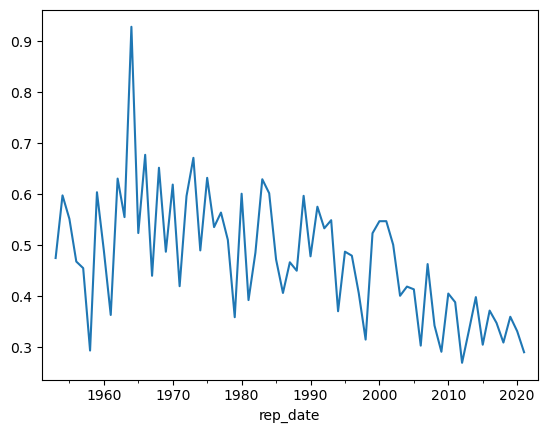

In [65]:
mean_anomaly = anomaly_df.abs().mean(axis=1)
mean_anomaly.plot()
#plt.ylim(0.2,0.6)
mean_mean = mean_anomaly.mean()
#plt.axhline(y=0,c='grey')
#plt.axhline(y=mean_mean,c='grey',linestyle='--')


1018610
1018620
1021830
1026270
1031110
1032730
1035940
1037650
1040390
1077500
1084350
1096450
1096630
1100030
1108447
1113540
1114740
1126150
1126510
1145730
1154200
1163780
1176750
3011880
3012208
3015520
3016800
3025480
3031093
3031920
3033880
3034480
3036240
3050520
3053520
3063680
3067370
4016560
4028040
4045600
4056240
4057120
1020270
1025370
4015320
3081680
3012210
1141455
4043920
3063685
1018642
1036206
1038205
1091169
1098940
1123970
1152102
1160899
1176751
3012205
3035201
3062241
4019035
1114741
1086556
1100120
1166945
3012295
4028060
4047240
4055736
3062244
4065055
4036844
1128551
3053520.1
3062244.1
3067370.1
3081680.1
4015320.1
4016560.1
4019035.1
4028040.1
4036844.1
4045600.1
4056240.1
4057120.1
1018610.1
1018620.1
1020270.1
1021830.1
1025370.1
1026270.1
1032730.1
1038205.1
1077500.1
1086556.1
1096450.1
1096630.1
1098940.1
1100030.1
1108447.1
1113540.1
1114741.1
1123970.1
1126150.1
1126510.1
1141455.1
1152102.1
1160899.1
1163780.1
1176751.1
3011880.1
3012205.1
3012208.1


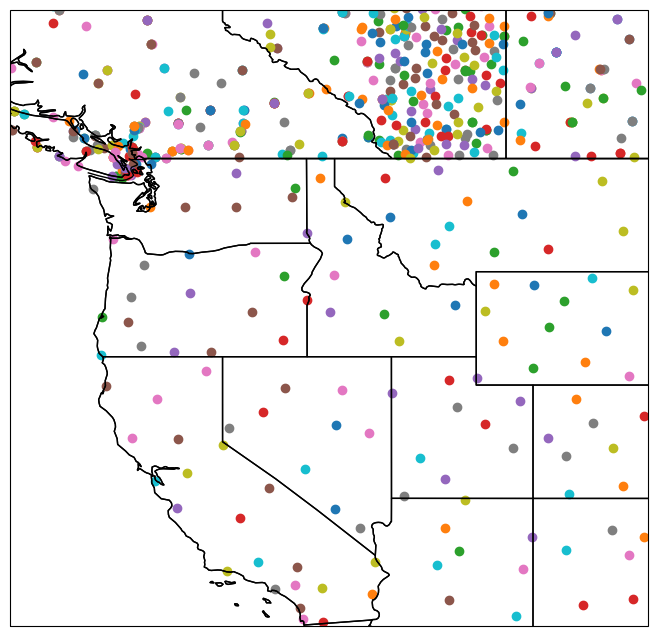

In [140]:
fig,axs = plt.subplots(figsize=(10,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

for station in full_study_area_FWI.columns:
            
    print(station)
    
    station = station.split('.')[0]

    lat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]
    lat = lat_lon.values[0][0]
    lon = lat_lon.values[0][1]+360
        
    axs.scatter(lon,lat)
            
axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)
axs.set_extent([232.5,255, 32.5,54.18])
       

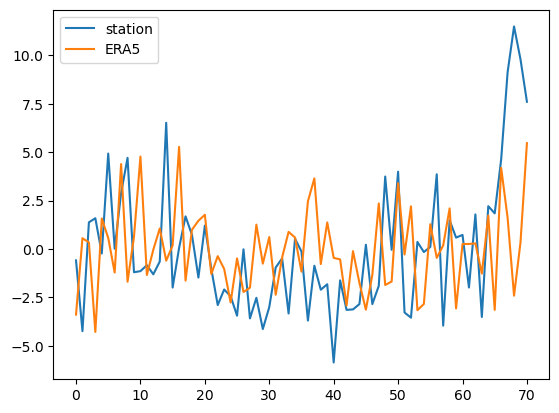

In [88]:
ts = full_study_area_FWI.mean(axis=1).values
model_ts = ERA5.mean(['latitude','longitude']).values
plt.plot(ts-ts.mean(),label='station')
plt.plot(model_ts - model_ts.mean(),label='ERA5')

plt.legend()

In [90]:
full_study_area_FWI.mean(axis=1).values

rep_date
1953-12-31    13.713772
1954-12-31    10.057935
1955-12-31    15.680915
1956-12-31    15.891491
1957-12-31    14.071896
                ...    
2019-12-31    18.930672
2020-12-31    23.433784
2021-12-31    25.798799
2022-12-31    24.105594
2023-12-31    21.908608
Length: 71, dtype: float64

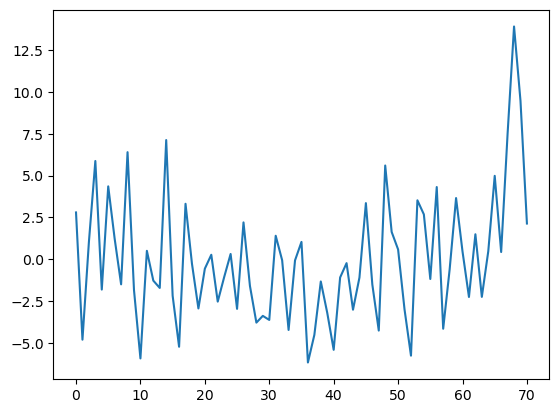

In [89]:
plt.plot((ts - ts.mean()) - (model_ts - model_ts.mean()))